# FIAP Tech Challenge — Fase 4
## Modelo LSTM para Previsão do Fechamento — PETR4.SA

Esta versão reorganiza a v5 com foco em uma avaliação mais confiável:

1. Carregamento dos dados históricos da PETR4
2. Feature engineering com retornos, volatilidade, momentum e médias móveis
3. Normalização relativa por janela para reduzir dependência do preço absoluto
4. Criação das janelas no dataset completo
5. Split temporal pelo índice do alvo, evitando perda de janelas em validação/teste
6. Modelo LSTM em PyTorch
7. Avaliação com MAE, RMSE, MAPE, acurácia direcional e baseline
8. Salvamento do modelo e artefatos de pré-processamento

A previsão final continua sendo de **valor de fechamento em R$**, mas o modelo aprende padrões relativos dentro de cada janela.


---
## 1. Setup e imports


In [1]:
import os
import json
import pickle
from copy import deepcopy
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    plt.style.use("seaborn-v0_8-darkgrid")
except Exception:
    pass

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))


Usando dispositivo: cuda
NVIDIA GeForce RTX 4070 SUPER


---
## 2. Configurações do experimento


In [2]:
SYMBOL = "PETR4.SA"
DATA_PATH = os.path.join("..", "data", "raw", "petr4_daily.csv")

# Use None para usar todo o histórico disponível.
# Para reduzir mudança de regime, use algo como 1000 ou 1500 pregões.
RECENT_DAYS = 1000

WINDOW_SIZE = 30
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

BATCH_SIZE = 32
EPOCHS = 150
LEARNING_RATE = 1e-3
#WEIGHT_DECAY = 1e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 20
GRAD_CLIP = 1.0

#HIDDEN_SIZE = 64
#NUM_LAYERS = 2
#DROPOUT = 0.20

HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.2

print("Configuração:")
print(f"SYMBOL:       {SYMBOL}")
print(f"RECENT_DAYS:  {RECENT_DAYS}")
print(f"WINDOW_SIZE:  {WINDOW_SIZE}")
print(f"Modelo:       hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, dropout={DROPOUT}")


Configuração:
SYMBOL:       PETR4.SA
RECENT_DAYS:  1000
WINDOW_SIZE:  30
Modelo:       hidden=32, layers=1, dropout=0.2


---
## 3. Carregamento robusto dos dados

O notebook tenta carregar `../data/raw/petr4_daily.csv`. Caso o arquivo não exista, tenta baixar via `yfinance`.


In [3]:
REQUIRED_COLS = ["Open", "High", "Low", "Close", "Volume"]
OPTIONAL_COLS = ["Adj Close"]
KNOWN_COLS = REQUIRED_COLS + OPTIONAL_COLS


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza colunas vindas de CSV comum ou CSV do yfinance com MultiIndex."""
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        new_cols = []
        for col in df.columns:
            chosen = None
            for part in col:
                if str(part).strip() in KNOWN_COLS:
                    chosen = str(part).strip()
                    break
            if chosen is None:
                chosen = str(col[0]).strip()
            new_cols.append(chosen)
        df.columns = new_cols
    else:
        df.columns = [str(c).strip() for c in df.columns]
        rename_map = {}
        for c in df.columns:
            for known in KNOWN_COLS:
                if c == known or c.startswith(known):
                    rename_map[c] = known
        df = df.rename(columns=rename_map)

    # Data como índice
    if not isinstance(df.index, pd.DatetimeIndex):
        date_candidates = ["Date", "Datetime", "data", "Data", "date", "datetime"]
        date_col = next((c for c in date_candidates if c in df.columns), None)
        if date_col is not None:
            df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
            df = df.set_index(date_col)
        else:
            df.index = pd.to_datetime(df.index, errors="coerce")
    else:
        df.index = pd.to_datetime(df.index, errors="coerce")

    df = df.loc[df.index.notna()].copy()
    df.index.name = "Date"
    df = df.sort_index()

    # Converter numéricos
    for col in KNOWN_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def read_stock_csv(path: str) -> pd.DataFrame:
    """Lê CSV comum ou CSV exportado pelo yfinance com duas linhas de cabeçalho."""
    errors = []

    # Tentativa 1: yfinance com MultiIndex de colunas
    try:
        df_multi = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
        df_multi = normalize_columns(df_multi)
        if all(c in df_multi.columns for c in REQUIRED_COLS):
            return df_multi
    except Exception as exc:
        errors.append(f"multi-header: {exc}")

    # Tentativa 2: CSV comum
    try:
        df_plain = pd.read_csv(path)
        df_plain = normalize_columns(df_plain)
        if all(c in df_plain.columns for c in REQUIRED_COLS):
            return df_plain
    except Exception as exc:
        errors.append(f"plain csv: {exc}")

    raise ValueError("Não foi possível carregar o CSV. Erros: " + " | ".join(errors))


if os.path.exists(DATA_PATH):
    df = read_stock_csv(DATA_PATH)
    print(f"Dados carregados de: {DATA_PATH}")
else:
    print("Arquivo local não encontrado. Tentando baixar com yfinance...")
    import yfinance as yf

    df = yf.download(
        SYMBOL,
        start="2015-01-01",
        interval="1d",
        auto_adjust=False,
        progress=False,
    )
    df = normalize_columns(df)

missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing}")

df = df[REQUIRED_COLS + [c for c in OPTIONAL_COLS if c in df.columns]].dropna(subset=REQUIRED_COLS)
df = df.loc[df["Volume"] > 0].copy()

print(df.tail())
print("Período:", df.index.min().date(), "até", df.index.max().date())
print("Registros:", len(df))


Dados carregados de: ..\data\raw\petr4_daily.csv
                 Open       High        Low      Close    Volume
Date                                                            
2026-05-04  49.279999  49.849998  48.919998  49.340000  41319600
2026-05-05  48.880001  49.029999  48.330002  48.660000  28066500
2026-05-06  46.709999  47.490002  46.590000  47.270000  62009100
2026-05-07  46.400002  46.650002  45.200001  46.220001  71214500
2026-05-08  46.389999  46.549999  45.669998  45.669998  32914200
Período: 2019-01-02 até 2026-05-08
Registros: 1828


---
## 4. Análise exploratória rápida


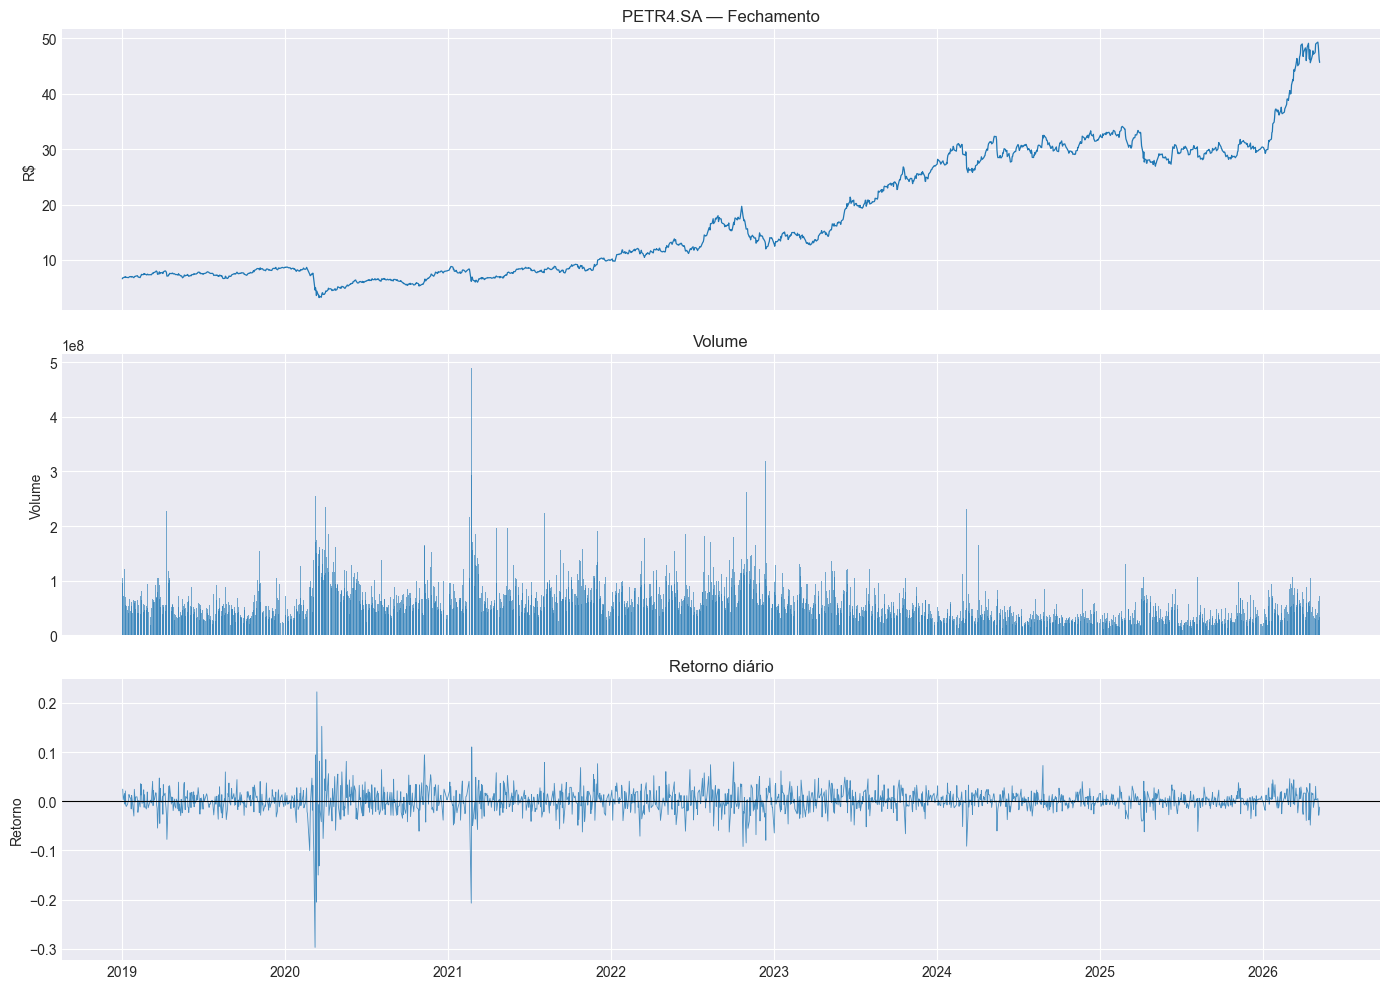

Retorno médio diário: 0.001381
Volatilidade diária:  0.025026


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["Close"], linewidth=0.9)
axes[0].set_title(f"{SYMBOL} — Fechamento")
axes[0].set_ylabel("R$")

axes[1].bar(df.index, df["Volume"], width=2, alpha=0.6)
axes[1].set_title("Volume")
axes[1].set_ylabel("Volume")

df["Return"] = df["Close"].pct_change()
axes[2].plot(df.index, df["Return"], linewidth=0.6, alpha=0.8)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Retorno diário")
axes[2].set_ylabel("Retorno")

plt.tight_layout()
plt.show()

print(f"Retorno médio diário: {df['Return'].mean():.6f}")
print(f"Volatilidade diária:  {df['Return'].std():.6f}")


---
## 5. Feature engineering

As features foram separadas em dois grupos:

- **Features de preço**: normalizadas por janela, dividindo pelo fechamento inicial da janela.
- **Features estacionárias/relativas**: normalizadas com `StandardScaler` ajustado apenas no treino.


In [5]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))

    data["SMA_7"] = data["Close"].rolling(window=7).mean()
    data["SMA_21"] = data["Close"].rolling(window=21).mean()
    data["SMA_50"] = data["Close"].rolling(window=50).mean()

    data["Volatility_21"] = data["Log_Return"].rolling(window=21).std()

    data["HL_Range"] = (data["High"] - data["Low"]) / data["Close"]
    data["Momentum_5"] = data["Close"] / data["Close"].shift(5) - 1
    data["Momentum_21"] = data["Close"] / data["Close"].shift(21) - 1

    volume_mean = data["Volume"].rolling(window=21).mean()
    volume_std = data["Volume"].rolling(window=21).std().replace(0, np.nan)
    data["Volume_Zscore"] = (data["Volume"] - volume_mean) / volume_std

    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    return data


df_feat = create_features(df)

if RECENT_DAYS is not None:
    df_feat = df_feat.tail(RECENT_DAYS).copy()

PRICE_COLS = ["Close", "Open", "High", "Low", "SMA_7", "SMA_21"]
STATIONARY_COLS = ["Log_Return", "Volatility_21", "HL_Range", "Momentum_5", "Momentum_21", "Volume_Zscore"]
ALL_FEATURE_COLS = PRICE_COLS + STATIONARY_COLS
TARGET_COL = "Close"

print("Período após feature engineering:", df_feat.index.min().date(), "até", df_feat.index.max().date())
print("Registros após feature engineering:", len(df_feat))
print("Features:", ALL_FEATURE_COLS)
df_feat.tail()


Período após feature engineering: 2022-05-06 até 2026-05-08
Registros após feature engineering: 1000
Features: ['Close', 'Open', 'High', 'Low', 'SMA_7', 'SMA_21', 'Log_Return', 'Volatility_21', 'HL_Range', 'Momentum_5', 'Momentum_21', 'Volume_Zscore']


,Open,High,Low,Close,Volume,Return,Log_Return,SMA_7,SMA_21,SMA_50,Volatility_21,HL_Range,Momentum_5,Momentum_21,Volume_Zscore
Date,,,,,,,,,,,,,,,
2026-05-04,49.279999,49.849998,48.919998,49.340000,41319600,0.005297,0.005283,48.171429,47.568626,44.980017,0.024440,0.018849,0.046226,0.027261,-0.444606
2026-05-05,48.880001,49.029999,48.330002,48.660000,28066500,-0.013782,-0.013878,48.298571,47.659688,45.206951,0.023837,0.014385,0.027232,0.040907,-1.023415
2026-05-06,46.709999,47.490002,46.590000,47.270000,62009100,-0.028566,-0.028981,48.314286,47.647903,45.402927,0.024507,0.019040,-0.005261,-0.005208,0.647963
2026-05-07,46.400002,46.650002,45.200001,46.220001,71214500,-0.022213,-0.022463,48.150000,47.548995,45.565666,0.024659,0.031372,-0.055964,-0.043006,1.014710
2026-05-08,46.389999,46.549999,45.669998,45.669998,32914200,-0.011900,-0.011971,47.885714,47.444103,45.698062,0.024711,0.019269,-0.069478,-0.046012,-0.935814


---
## 6. Split temporal e scaler sem vazamento

O split é calculado por linha temporal, mas as janelas serão criadas no dataset completo. Depois, cada janela será enviada para treino/validação/teste de acordo com a **data do alvo**.

Isso evita perder `WINDOW_SIZE` amostras dentro da validação e do teste.


In [6]:
n = len(df_feat)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

if n <= WINDOW_SIZE + 10:
    raise ValueError("Poucos dados para criar janelas. Aumente RECENT_DAYS ou reduza WINDOW_SIZE.")

# Scaler das features estacionárias: fit apenas no treino
scaler_stat = StandardScaler()
scaler_stat.fit(df_feat.iloc[:train_end][STATIONARY_COLS].values)

print(f"Total:     {n} linhas")
print(f"Treino:    0 até {train_end - 1} ({train_end} linhas)")
print(f"Validação: {train_end} até {val_end - 1} ({val_end - train_end} linhas)")
print(f"Teste:     {val_end} até {n - 1} ({n - val_end} linhas)")

print(f"\nFaixa de preço treino: R${df_feat.iloc[:train_end]['Close'].min():.2f} – R${df_feat.iloc[:train_end]['Close'].max():.2f}")
print(f"Faixa de preço val:    R${df_feat.iloc[train_end:val_end]['Close'].min():.2f} – R${df_feat.iloc[train_end:val_end]['Close'].max():.2f}")
print(f"Faixa de preço teste:  R${df_feat.iloc[val_end:]['Close'].min():.2f} – R${df_feat.iloc[val_end:]['Close'].max():.2f}")


Total:     1000 linhas
Treino:    0 até 799 (800 linhas)
Validação: 800 até 899 (100 linhas)
Teste:     900 até 999 (100 linhas)

Faixa de preço treino: R$11.18 – R$34.12
Faixa de preço val:    R$28.10 – R$31.76
Faixa de preço teste:  R$29.25 – R$49.34


---
## 7. Criação das janelas no dataset completo

Para cada alvo no dia `i`:

- Entrada `X`: dias `i-WINDOW_SIZE` até `i-1`
- Alvo `y`: fechamento do dia `i`, representado como `Close[i] / Close[i-WINDOW_SIZE]`
- Reconstrução: `preço_previsto = ratio_previsto × anchor_price`
- Baseline: `preço_previsto = Close[i-1]`

Assim, o modelo usa apenas dados passados para prever o próximo fechamento.


In [7]:
def create_windowed_sequences_full(
    df_feat: pd.DataFrame,
    window_size: int,
    scaler_stat: StandardScaler,
    price_cols: list[str],
    stationary_cols: list[str],
    all_feature_cols: list[str],
):
    data = df_feat[all_feature_cols].values.astype(np.float32)
    closes = df_feat["Close"].values.astype(np.float32)
    dates = df_feat.index.to_numpy()

    price_idx = [all_feature_cols.index(c) for c in price_cols]
    stat_idx = [all_feature_cols.index(c) for c in stationary_cols]

    X_seq, y_seq = [], []
    anchors, last_closes, target_closes, target_dates, target_rows = [], [], [], [], []

    for i in range(window_size, len(data)):
        # Janela usa somente passado: [i-window_size, ..., i-1]
        window = data[i - window_size : i].copy()

        anchor_price = closes[i - window_size]
        last_close = closes[i - 1]
        target_close = closes[i]

        if not np.isfinite(anchor_price) or anchor_price <= 0:
            continue

        # Preços relativos ao início da janela
        window[:, price_idx] = window[:, price_idx] / anchor_price

        # Features estacionárias padronizadas por scaler fitado no treino
        window[:, stat_idx] = scaler_stat.transform(window[:, stat_idx])

        target_ratio = target_close / anchor_price

        X_seq.append(window)
        y_seq.append(target_ratio)
        anchors.append(anchor_price)
        last_closes.append(last_close)
        target_closes.append(target_close)
        target_dates.append(dates[i])
        target_rows.append(i)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32).reshape(-1, 1),
        np.asarray(anchors, dtype=np.float32),
        np.asarray(last_closes, dtype=np.float32),
        np.asarray(target_closes, dtype=np.float32),
        np.asarray(target_dates),
        np.asarray(target_rows),
    )


(
    X_all,
    y_all,
    anchors_all,
    last_close_all,
    real_close_all,
    target_dates_all,
    rows_all,
) = create_windowed_sequences_full(
    df_feat=df_feat,
    window_size=WINDOW_SIZE,
    scaler_stat=scaler_stat,
    price_cols=PRICE_COLS,
    stationary_cols=STATIONARY_COLS,
    all_feature_cols=ALL_FEATURE_COLS,
)

train_mask = rows_all < train_end
val_mask = (rows_all >= train_end) & (rows_all < val_end)
test_mask = rows_all >= val_end

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

anchors_train, anchors_val, anchors_test = anchors_all[train_mask], anchors_all[val_mask], anchors_all[test_mask]
last_close_test = last_close_all[test_mask]
real_close_test = real_close_all[test_mask]
test_dates = pd.to_datetime(target_dates_all[test_mask])

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

if len(X_val) == 0 or len(X_test) == 0:
    raise ValueError("Validação ou teste ficou vazio. Aumente RECENT_DAYS, reduza WINDOW_SIZE ou ajuste os splits.")


X_train: (770, 30, 12)
X_val:   (100, 30, 12)
X_test:  (100, 30, 12)


---
## 8. DataLoaders


In [8]:
def to_dataloader(X, y, batch_size, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


train_loader = to_dataloader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader = to_dataloader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = to_dataloader(X_test, y_test, BATCH_SIZE, shuffle=False)

INPUT_SIZE = X_train.shape[2]
print("INPUT_SIZE:", INPUT_SIZE)
print("Batches treino:", len(train_loader))
print("Batches val:   ", len(val_loader))
print("Batches teste: ", len(test_loader))


INPUT_SIZE: 12
Batches treino: 25
Batches val:    4
Batches teste:  4


---
## 9. Modelo LSTM

A arquitetura segue o padrão da aula de arquiteturas de redes neurais: uma LSTM processa a sequência e a camada linear usa a saída do último passo temporal para regressão.


In [9]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=effective_dropout,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        last_step = self.dropout(last_step)
        return self.fc(last_step)


model = LSTMPredictor(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Parâmetros treináveis: {num_params:,}")


LSTMPredictor(
  (lstm): LSTM(12, 32, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Parâmetros treináveis: 5,921


---
## 10. Treinamento com early stopping


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)


def train_epoch(model, loader, criterion, optimizer, device, grad_clip):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


In [11]:
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10} | Status")
print("-" * 72)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP)
    val_loss = evaluate_loss(model, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
        status = "best"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{PATIENCE}"

    if epoch == 1 or epoch % 10 == 0 or status == "best":
        print(f"{epoch:6d} | {train_loss:12.6f} | {val_loss:12.6f} | {current_lr:10.2e} | {status}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping na época {epoch}.")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Melhor val_loss: {best_val_loss:.6f}")


 Epoch |   Train Loss |     Val Loss |         LR | Status
------------------------------------------------------------------------
     1 |     0.344623 |     0.001428 |   1.00e-03 | best
     3 |     0.013445 |     0.000667 |   1.00e-03 | best
     5 |     0.011186 |     0.000518 |   1.00e-03 | best
     6 |     0.010654 |     0.000514 |   1.00e-03 | best
     8 |     0.010252 |     0.000435 |   1.00e-03 | best
     9 |     0.008913 |     0.000420 |   1.00e-03 | best
    10 |     0.008253 |     0.000997 |   1.00e-03 | patience 1/20
    12 |     0.009406 |     0.000340 |   1.00e-03 | best
    19 |     0.006800 |     0.000330 |   5.00e-04 | best
    20 |     0.006853 |     0.000291 |   5.00e-04 | best
    22 |     0.006313 |     0.000287 |   5.00e-04 | best
    23 |     0.006454 |     0.000261 |   5.00e-04 | best
    30 |     0.006206 |     0.000268 |   2.50e-04 | patience 7/20
    31 |     0.006195 |     0.000249 |   2.50e-04 | best
    32 |     0.006230 |     0.000244 |   2.50e-04 | 

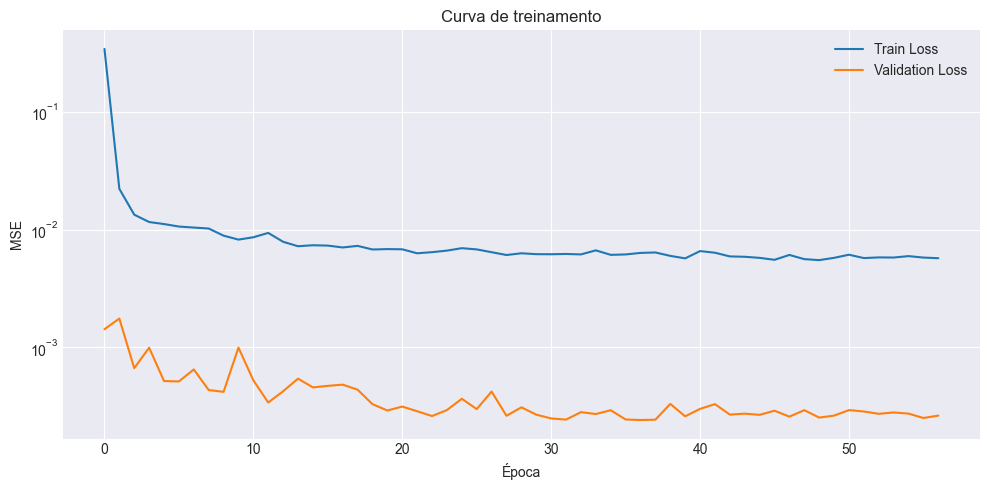

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train Loss")
ax.plot(val_losses, label="Validation Loss")
ax.set_title("Curva de treinamento")
ax.set_xlabel("Época")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()


---
## 11. Avaliação: LSTM vs baseline

O baseline usado é: **preço de amanhã = último fechamento conhecido**. Esse baseline é forte para séries financeiras e ajuda a evitar uma interpretação exagerada do gráfico.


In [13]:
def predict_ratio(model, loader, device):
    model.eval()
    preds_all = []
    targets_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            preds_all.append(preds)
            targets_all.append(y_batch.numpy())

    return np.vstack(preds_all), np.vstack(targets_all)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE": float(mape),
    }


pred_ratio, true_ratio = predict_ratio(model, test_loader, DEVICE)

# Reconstrução em preço real
pred_close = pred_ratio.reshape(-1) * anchors_test
true_close = true_ratio.reshape(-1) * anchors_test

# Sanity check: deve bater com real_close_test
print("Diferença máxima true_close vs real_close_test:", np.max(np.abs(true_close - real_close_test)))

baseline_close = last_close_test.copy()

lstm_metrics = regression_metrics(true_close, pred_close)
baseline_metrics = regression_metrics(true_close, baseline_close)

# Direção: compara movimento do fechamento alvo em relação ao último fechamento conhecido
true_direction = (true_close - last_close_test) > 0
pred_direction = (pred_close - last_close_test) > 0
baseline_direction = (baseline_close - last_close_test) > 0  # sempre False, pois baseline não muda

directional_accuracy = float(np.mean(true_direction == pred_direction) * 100)
baseline_directional_accuracy = float(np.mean(true_direction == baseline_direction) * 100)

print("=" * 60)
print("MÉTRICAS — LSTM")
print("=" * 60)
print(f"MAE:                 R$ {lstm_metrics['MAE']:.4f}")
print(f"RMSE:                R$ {lstm_metrics['RMSE']:.4f}")
print(f"MAPE:                {lstm_metrics['MAPE']:.2f}%")
print(f"Acurácia direcional: {directional_accuracy:.2f}%")

print("\n" + "=" * 60)
print("MÉTRICAS — BASELINE amanhã = último fechamento")
print("=" * 60)
print(f"MAE:                 R$ {baseline_metrics['MAE']:.4f}")
print(f"RMSE:                R$ {baseline_metrics['RMSE']:.4f}")
print(f"MAPE:                {baseline_metrics['MAPE']:.2f}%")
print(f"Acurácia direcional: {baseline_directional_accuracy:.2f}%")

print("\nGanho relativo vs baseline:")
for metric in ["MAE", "RMSE", "MAPE"]:
    gain = (baseline_metrics[metric] - lstm_metrics[metric]) / baseline_metrics[metric] * 100
    print(f"{metric}: {gain:.2f}%")


Diferença máxima true_close vs real_close_test: 3.8146973e-06
MÉTRICAS — LSTM
MAE:                 R$ 0.7726
RMSE:                R$ 1.0027
MAPE:                1.90%
Acurácia direcional: 50.00%

MÉTRICAS — BASELINE amanhã = último fechamento
MAE:                 R$ 0.6010
RMSE:                R$ 0.7913
MAPE:                1.46%
Acurácia direcional: 33.00%

Ganho relativo vs baseline:
MAE: -28.56%
RMSE: -26.71%
MAPE: -29.66%


---
## 12. Visualização dos resultados


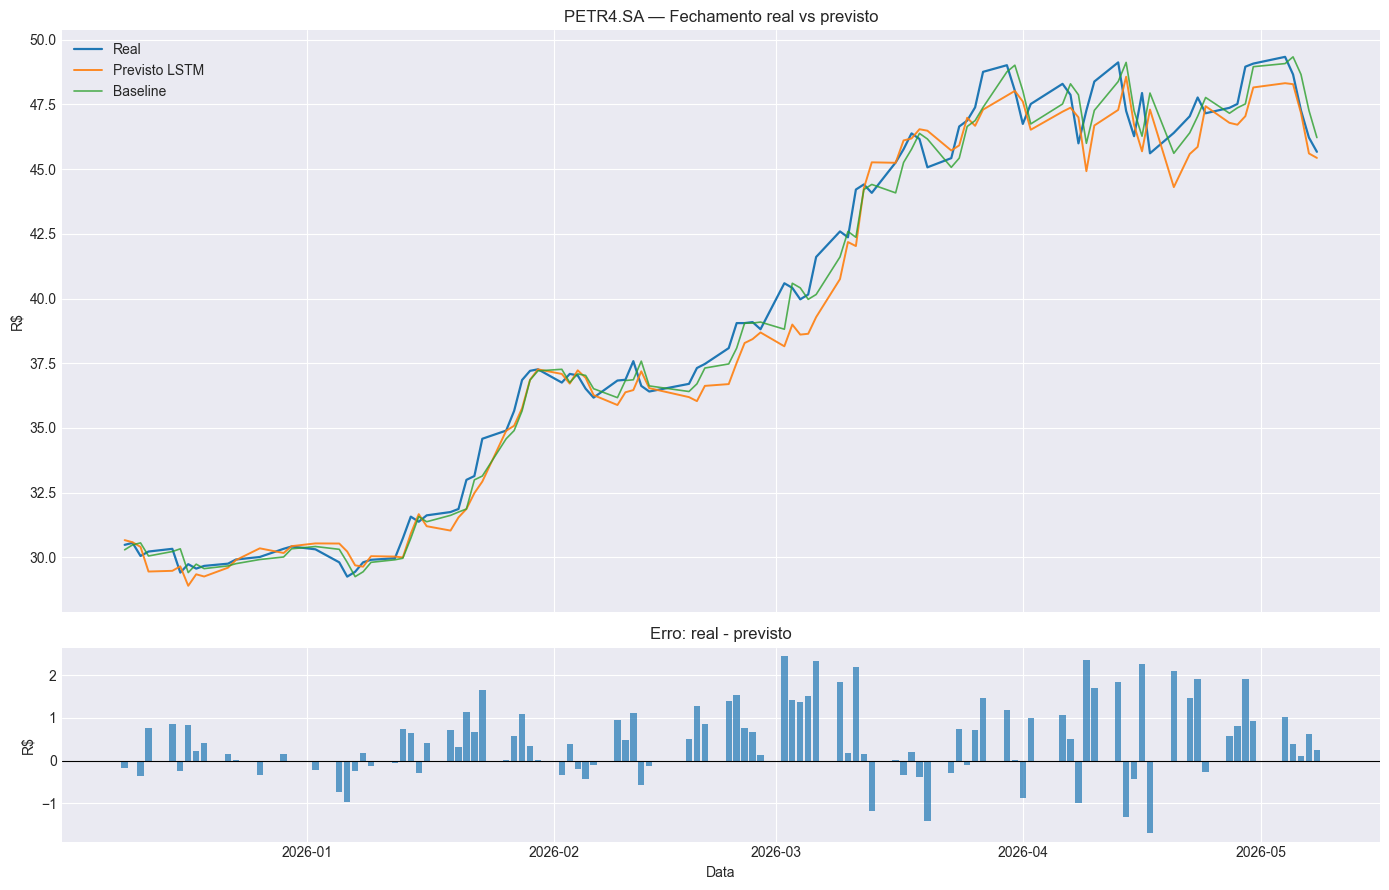

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

ax1 = axes[0]
ax1.plot(test_dates, true_close, label="Real", linewidth=1.6)
ax1.plot(test_dates, pred_close, label="Previsto LSTM", linewidth=1.4, alpha=0.9)
ax1.plot(test_dates, baseline_close, label="Baseline", linewidth=1.2, alpha=0.8)
ax1.set_title(f"{SYMBOL} — Fechamento real vs previsto")
ax1.set_ylabel("R$")
ax1.legend()

ax2 = axes[1]
errors = true_close - pred_close
ax2.bar(test_dates, errors, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Erro: real - previsto")
ax2.set_ylabel("R$")
ax2.set_xlabel("Data")

plt.tight_layout()
plt.show()


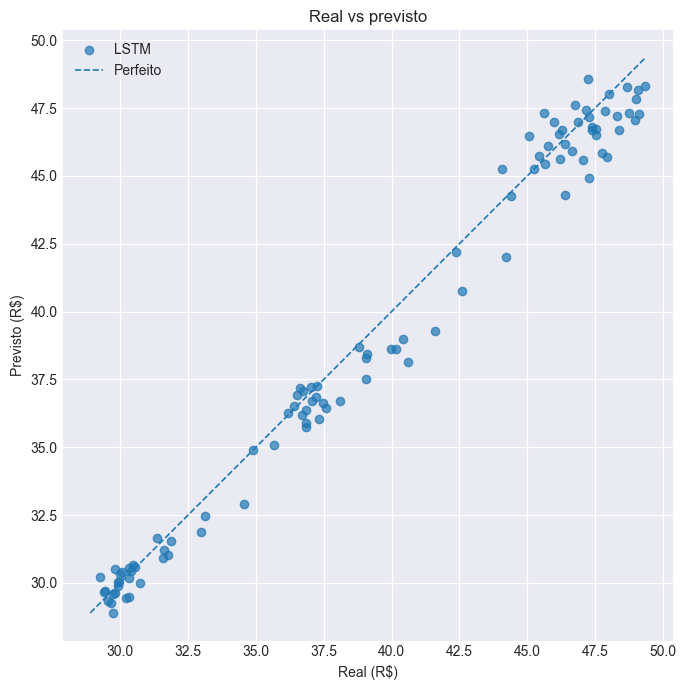

Correlação real vs previsto: 0.9921


In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(true_close, pred_close, alpha=0.7, label="LSTM")

min_val = min(true_close.min(), pred_close.min(), baseline_close.min())
max_val = max(true_close.max(), pred_close.max(), baseline_close.max())
ax.plot([min_val, max_val], [min_val, max_val], "--", linewidth=1.2, label="Perfeito")

ax.set_title("Real vs previsto")
ax.set_xlabel("Real (R$)")
ax.set_ylabel("Previsto (R$)")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

corr = np.corrcoef(true_close.reshape(-1), pred_close.reshape(-1))[0, 1]
print(f"Correlação real vs previsto: {corr:.4f}")


---
## 13. Salvamento do modelo e artefatos

Arquivos salvos:

- `model.pt`: pesos do modelo e metadados principais
- `preprocess.pkl`: scaler e lista de features
- `metrics.json`: métricas da LSTM e do baseline


In [16]:
MODEL_DIR = os.path.join("..", "src", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(MODEL_DIR, f"lstm_petr4_v6_{timestamp}.pt")
preprocess_path = os.path.join(MODEL_DIR, f"preprocess_petr4_v6_{timestamp}.pkl")
metrics_path = os.path.join(MODEL_DIR, f"metrics_petr4_v6_{timestamp}.json")

metadata = {
    "symbol": SYMBOL,
    "target_col": TARGET_COL,
    "window_size": WINDOW_SIZE,
    "recent_days": RECENT_DAYS,
    "features": ALL_FEATURE_COLS,
    "price_cols": PRICE_COLS,
    "stationary_cols": STATIONARY_COLS,
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "train_end_row": int(train_end),
    "val_end_row": int(val_end),
    "model_params": {
        "input_size": int(INPUT_SIZE),
        "hidden_size": int(HIDDEN_SIZE),
        "num_layers": int(NUM_LAYERS),
        "dropout": float(DROPOUT),
    },
    "metrics": {
        "lstm": lstm_metrics,
        "baseline_last_close": baseline_metrics,
        "directional_accuracy_lstm_pct": directional_accuracy,
        "directional_accuracy_baseline_pct": baseline_directional_accuracy,
    },
    "created_at": timestamp,
}

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "metadata": metadata,
    },
    model_path,
)

with open(preprocess_path, "wb") as f:
    pickle.dump(
        {
            "scaler_stat": scaler_stat,
            "metadata": metadata,
        },
        f,
    )

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metadata["metrics"], f, indent=2, ensure_ascii=False)

print("Arquivos salvos:")
print("-", model_path)
print("-", preprocess_path)
print("-", metrics_path)


Arquivos salvos:
- ..\src\models\lstm_petr4_v6_20260513_200958.pt
- ..\src\models\preprocess_petr4_v6_20260513_200958.pkl
- ..\src\models\metrics_petr4_v6_20260513_200958.json


---
## 14. Sanity check: carregamento do modelo


In [17]:
checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
hp = checkpoint["metadata"]["model_params"]

loaded_model = LSTMPredictor(
    input_size=hp["input_size"],
    hidden_size=hp["hidden_size"],
    num_layers=hp["num_layers"],
    dropout=hp["dropout"],
)
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

with open(preprocess_path, "rb") as f:
    preprocess_artifact = pickle.load(f)

print("Modelo carregado com sucesso.")
print("Features:", checkpoint["metadata"]["features"])
print("Métricas:", checkpoint["metadata"]["metrics"])


Modelo carregado com sucesso.
Features: ['Close', 'Open', 'High', 'Low', 'SMA_7', 'SMA_21', 'Log_Return', 'Volatility_21', 'HL_Range', 'Momentum_5', 'Momentum_21', 'Volume_Zscore']
Métricas: {'lstm': {'MAE': 0.7726191878318787, 'RMSE': 1.0027062038005632, 'MAPE': 1.8990037441253662}, 'baseline_last_close': {'MAE': 0.6009891629219055, 'RMSE': 0.7913454098300875, 'MAPE': 1.4646317958831787}, 'directional_accuracy_lstm_pct': 50.0, 'directional_accuracy_baseline_pct': 33.0}


---
## 15. Exemplo de inferência para futura API

A API deverá receber histórico suficiente para calcular as features e montar a última janela. Na prática, envie mais que `WINDOW_SIZE`, pois as features usam médias/volatilidade de até 50 pregões.


In [18]:
def predict_next_close_from_df(recent_df: pd.DataFrame, model: nn.Module, scaler_stat: StandardScaler, metadata: dict, device="gpu"):
    """Exemplo simples de inferência usando um dataframe OHLCV recente."""
    recent_df = normalize_columns(recent_df)
    feat = create_features(recent_df)

    window_size = metadata["window_size"]
    all_feature_cols = metadata["features"]
    price_cols = metadata["price_cols"]
    stationary_cols = metadata["stationary_cols"]

    if len(feat) < window_size:
        raise ValueError(f"Histórico insuficiente após feature engineering. Necessário: {window_size}, recebido: {len(feat)}")

    feat = feat.tail(window_size).copy()
    data = feat[all_feature_cols].values.astype(np.float32)
    closes = feat["Close"].values.astype(np.float32)

    price_idx = [all_feature_cols.index(c) for c in price_cols]
    stat_idx = [all_feature_cols.index(c) for c in stationary_cols]

    anchor_price = closes[0]
    window = data.copy()
    window[:, price_idx] = window[:, price_idx] / anchor_price
    window[:, stat_idx] = scaler_stat.transform(window[:, stat_idx])

    X = torch.tensor(window.reshape(1, window_size, len(all_feature_cols)), dtype=torch.float32).to(device)

    model = model.to(device)
    model.eval()
    with torch.no_grad():
        pred_ratio = model(X).cpu().numpy()[0, 0]

    pred_close = float(pred_ratio * anchor_price)
    last_close = float(closes[-1])

    return {
        "predicted_close": pred_close,
        "last_close": last_close,
        "predicted_variation_pct": (pred_close / last_close - 1) * 100,
    }


# Exemplo usando o próprio dataframe local
example_pred = predict_next_close_from_df(df.tail(120), loaded_model, preprocess_artifact["scaler_stat"], checkpoint["metadata"])
example_pred


RuntimeError: Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: gpu

---
## Conclusão técnica

Esta versão mantém o objetivo do Tech Challenge — prever fechamento com LSTM — mas evita depender diretamente de preço absoluto. O modelo aprende padrões relativos dentro da janela e a avaliação compara o resultado contra um baseline simples.

Para o vídeo e documentação, deixe claro que o modelo é uma demonstração de pipeline de Deep Learning e MLOps, não uma recomendação financeira.
